In [22]:
 # Required packages
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



```
de → 0
es → 1
fr → 2
it → 3
```



#Premilinary Analysis


In [10]:
df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/New_experiments/Shining-Through-Data.csv")
df.head()


,Unnamed: 0,afile,alang,akorp,astatus,sentlength,ppron,possdet,indef,cconj,...,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp,L1
0,6,9,en,preprocessed,L2,51.875000,0.060241,0.004819,0.002410,2.500000,...,3.939911,2.099410,0.050000,0.491667,0.041667,0.087500,0.000000,0.112500,0.216667,es
1,8,11,en,preprocessed,L2,22.769231,0.064189,0.037162,0.003378,0.538462,...,3.776333,1.435866,0.141026,0.371795,0.019231,0.205128,0.019231,0.000000,0.089744,de
2,9,12,en,preprocessed,L2,21.866667,0.054878,0.006098,0.006098,0.666667,...,3.586628,1.380520,0.013333,0.457778,0.046667,0.166667,0.013333,0.035556,0.066667,de
3,19,22,en,preprocessed,L2,34.916667,0.124105,0.023866,0.004773,1.750000,...,3.641703,1.688192,0.034226,0.132143,0.043155,0.220238,0.031250,0.236409,0.135913,es
4,20,23,en,preprocessed,L2,18.636364,0.039024,0.017073,0.000000,0.909091,...,3.076063,1.286282,0.056818,0.147727,0.069697,0.060606,0.069697,0.022727,0.072727,de


In [11]:
df = df.drop(columns="sentlength",axis = "columns")
df = df.drop(columns=["Unnamed: 0","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})

In [14]:
num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]

print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


In [15]:
print(df.columns.tolist())
print(df.shape)

['dataset_name', 'ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'L1']
(142540, 46)


## Problem with New dataset - Data Imbalance

In [16]:
l1_values = ["es", "de", "fr", "it"]
df_filtered = df[df["L1"].isin(l1_values)]

# Count of L1 per L2
count_per_L2 = df_filtered.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)



L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167


In [17]:
# data balancing

df_L2 = df[df['dataset_name'] == 'L2']
df_TR = df[df['dataset_name'] == 'TR']

df_TR_downsampled = df_TR.sample(n=len(df_L2), random_state=42)

df_balanced = pd.concat([df_L2, df_TR_downsampled], ignore_index=True)

to_drop = [c for c in ['L1','dataset_name','cluster','kmeans_labels'] if c in df_balanced.columns]
feature_cols = [c for c in df_balanced.columns if c not in to_drop]

df_balanced = df_balanced.dropna()
X_s = df_balanced[feature_cols].values
y_balanced = df_balanced['L1'].values  # target: L1

#Feature importance using a tree-based classifier

Text(0.5, 1.0, 'Top 10 Feature Importances using RandomeForestClassifier')

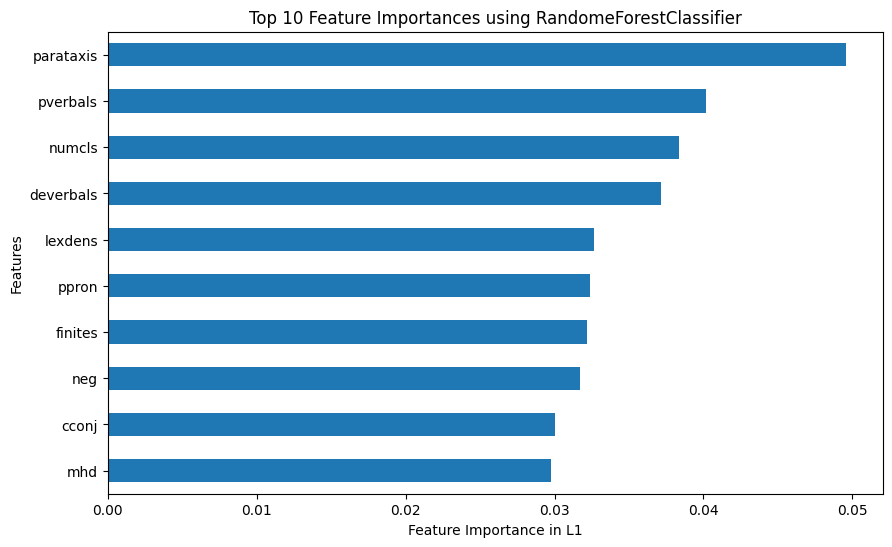

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_s, y_balanced, stratify=y_balanced,random_state=42)
rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
top_features = importances.head(10)[::-1]# reverses the top 20 features for correct horizontal orientation

ax = top_features.plot.barh(figsize=(10,6))
ax.set_xlabel("Feature Importance in L1")   # X-axis label
ax.set_ylabel("Features")             # Y-axis label
ax.set_title("Top 10 Feature Importances using RandomeForestClassifier")


In [46]:
os.makedirs("/content/plots_RF", exist_ok=True)

# top 10 features
top10_RF = list(top_features.sort_values(ascending=False).head(10).index)

# create the 8-class column correctly
df_plot = df_balanced.copy()
df_plot['class'] = df_plot['dataset_name'].astype(str) + "_" + df_plot['L1'].astype(str)  # e.g. "L2_es"

# classes in correct order
classes = ["L2_es","L2_de","L2_fr","L2_it","TR_es","TR_de","TR_fr","TR_it"]

# coerce features to numeric safely
for f in top10_RF:
    df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

# create plots and save individually
for feat in top10_RF:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='class', y=feat, data=df_plot, order=classes)
    plt.title(feat)
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # save each feature individually
    plt.savefig(f"/content/plots_RF/{feat}.png", dpi=300)
    plt.close()   # important to avoid overlap


for feat in top10_RF:
    plt.figure(figsize=(8,4))

    # KDE plot for all classes overlaid
    for cls in classes:
        subset = df_plot[df_plot['class'] == cls]
        if not subset.empty:
            sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4)

    plt.title(f"KDE of {feat} by class")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    # save individually
    plt.savefig(f"/content/plots_RF/{feat}_KDE.png", dpi=300)
    plt.close()


#SelectKBEST

In [47]:

#selectbest
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_s, y_balanced)
top_idx = selector.get_support(indices=True)
top10_SelectKBEST = [feature_cols[i] for i in top_idx]

print("Top 10 features by ANOVA F-test:", top10_SelectKBEST)

os.makedirs("/content/plots_SelectKBest", exist_ok=True)

# coerce features to numeric safely
for f in top10_SelectKBEST:
    df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

# create plots and save individually
for feat in top10_SelectKBEST:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='class', y=feat, data=df_plot, order=classes)
    plt.title(feat)
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # save each feature individually
    plt.savefig(f"/content/plots_SelectKBest/{feat}.png", dpi=300)
    plt.close()   # important to avoid overlap


for feat in top10_SelectKBEST:
    plt.figure(figsize=(8,4))

    # KDE plot for all classes overlaid
    for cls in classes:
        subset = df_plot[df_plot['class'] == cls]
        if not subset.empty:
            sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4)

    plt.title(f"KDE of {feat} by class")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    # save individually
    plt.savefig(f"/content/plots_SelectKBest/{feat}_KDE.png", dpi=300)
    plt.close()


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 features by ANOVA F-test: ['ppron', 'relativ', 'copula', 'pverbals', 'deverbals', 'neg', 'numcls', 'nnargs', 'mhd', 'aux']


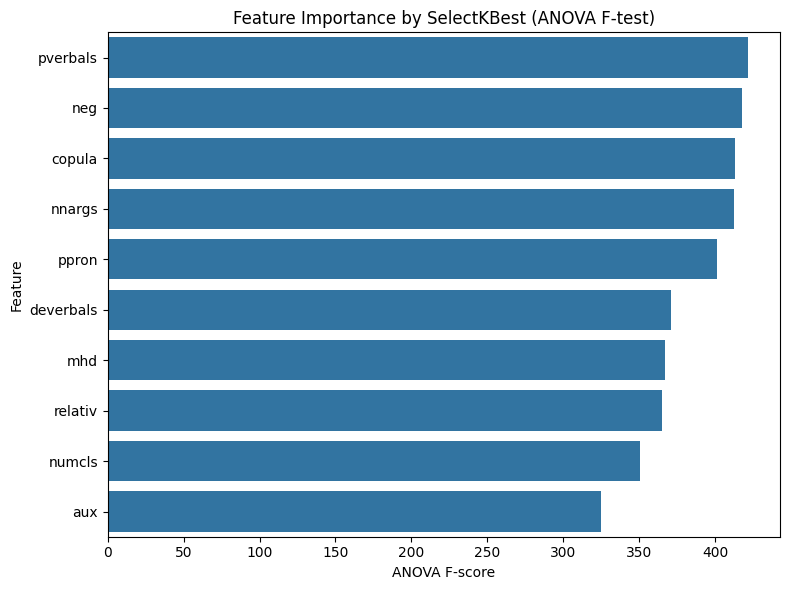

In [48]:
# Get the F-scores and p-values
f_scores = selector.scores_[top_idx]
p_values = selector.pvalues_[top_idx]

# Sort descending for horizontal bar plot
importance_df = pd.DataFrame({
    'Feature': top10_SelectKBEST,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)  # now highest F-score on top

# Plot horizontal bar plot
plt.figure(figsize=(8,6))
sns.barplot(x='F_score', y='Feature', data=importance_df)
plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")
plt.title("Feature Importance by SelectKBest (ANOVA F-test)")
plt.tight_layout()
plt.savefig("./plots_SelectKBest/Top10_Feature_Importance_desc.png", dpi=300)
plt.show()


In [49]:
!zip -r plots_SelectKBest.zip plots_SelectKBest


  adding: plots_SelectKBest/ (stored 0%)
  adding: plots_SelectKBest/nnargs_KDE.png (deflated 6%)
  adding: plots_SelectKBest/copula.png (deflated 21%)
  adding: plots_SelectKBest/pverbals.png (deflated 22%)
  adding: plots_SelectKBest/aux_KDE.png (deflated 7%)
  adding: plots_SelectKBest/Top10_Feature_Importance_desc.png (deflated 29%)
  adding: plots_SelectKBest/neg.png (deflated 21%)
  adding: plots_SelectKBest/neg_KDE.png (deflated 15%)
  adding: plots_SelectKBest/pverbals_KDE.png (deflated 13%)
  adding: plots_SelectKBest/ppron_KDE.png (deflated 10%)
  adding: plots_SelectKBest/numcls.png (deflated 23%)
  adding: plots_SelectKBest/copula_KDE.png (deflated 11%)
  adding: plots_SelectKBest/deverbals_KDE.png (deflated 11%)
  adding: plots_SelectKBest/relativ.png (deflated 21%)
  adding: plots_SelectKBest/mhd_KDE.png (deflated 9%)
  adding: plots_SelectKBest/deverbals.png (deflated 20%)
  adding: plots_SelectKBest/numcls_KDE.png (deflated 12%)
  adding: plots_SelectKBest/ppron.png (de

In [36]:
!zip -r plots_RF.zip plots_RF

updating: plots_RF/ (stored 0%)
updating: plots_RF/nnargs_KDE.png (deflated 6%)
updating: plots_RF/lexdens.png (deflated 21%)
updating: plots_RF/pverbals.png (deflated 22%)
updating: plots_RF/neg.png (deflated 21%)
updating: plots_RF/neg_KDE.png (deflated 15%)
updating: plots_RF/lexdens_KDE.png (deflated 9%)
updating: plots_RF/cconj.png (deflated 21%)
updating: plots_RF/pverbals_KDE.png (deflated 13%)
updating: plots_RF/numcls.png (deflated 23%)
updating: plots_RF/finites_KDE.png (deflated 6%)
updating: plots_RF/parataxis.png (deflated 19%)
updating: plots_RF/deverbals_KDE.png (deflated 11%)
updating: plots_RF/parataxis_KDE.png (deflated 13%)
updating: plots_RF/mhd_KDE.png (deflated 9%)
updating: plots_RF/deverbals.png (deflated 20%)
updating: plots_RF/numcls_KDE.png (deflated 12%)
updating: plots_RF/mhd.png (deflated 23%)
updating: plots_RF/nnargs.png (deflated 22%)
updating: plots_RF/finites.png (deflated 20%)
updating: plots_RF/cconj_KDE.png (deflated 10%)
  adding: plots_RF/ppron_K